# Sweden national resource and emission accounts — v4

**EXIOBASE:** v3.10.1 (March 2026) — `IOT_2024_pxp`.

**Root cause of GHG CBA = 0 (resolved in v4).** All three previous versions
tried to fix an index problem that turned out not to exist. The real issue is
that `pymrio.calc_all()` produces a broken `air_emissions.S` matrix: it is
numerically zero for all GHG stressor rows globally. Because `D_cba = S @ L @ Y`,
D_cba is also zero. Because Step 7 used `exio.air_emissions.S @ exio.L`, that
was zero too.

`D_pba` is NOT affected because pymrio computes it directly from `F`
(not through `S`), which is why PBA was always non-zero.

**Fix:** Bypass `pymrio.S` entirely for `air_emissions`. Compute the intensity
matrix manually as `S_air = F.div(x, axis=1)`, then derive M and the footprint
from scratch. The same manual approach is used throughout Steps 4–7.

**Household emissions (F_Y):** direct GHG from final demand (household driving,
heating, etc.) are stored in `air_emissions/F_Y`. These are added on top of the
supply-chain footprint to give the complete consumption-based account.

In [1]:
import pymrio
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import logging, time, zipfile

logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s %(levelname)s %(message)s')
log = logging.getLogger(__name__)

## Configuration

In [2]:
EXIOBASE_PATH = Path('C:/EXIOBASE3/IOT_2024_pxp.zip')
if not EXIOBASE_PATH.exists():
    raise FileNotFoundError(f'EXIOBASE file not found: {EXIOBASE_PATH}')

UNIT_TXT_PATH = zipfile.ZipFile(EXIOBASE_PATH).open('air_emissions/unit.txt')

OUTPUT_DIR = Path('./results_sweden')
OUTPUT_DIR.mkdir(exist_ok=True)

SWEDEN_CODE = 'SE'
BASE_YEAR   = 2024

## Step 1: GHG row mapping from unit.txt

In [3]:
def build_ghg_mapping(unit_txt_path):
    df = pd.read_csv(unit_txt_path, sep='\t', header=0)
    if df.shape[1] == 3:
        df.columns = ['stressor', 'compartment', 'unit']
        df['stressor'] = (df['stressor'].str.strip()
                          + ' - ' + df['compartment'].str.strip())
    elif df.shape[1] == 2:
        df.columns = ['stressor', 'unit']
    else:
        raise ValueError(f'Unexpected unit.txt: {df.shape[1]} columns')

    stressors = df['stressor'].tolist()
    units = dict(zip(df['stressor'], df['unit']))

    GWP = {'CO2': 1, 'CH4': 28, 'N2O': 265, 'SF6': 23500}

    FOSSIL = [
        'CO2 - combustion', 'CO2 - non combustion - Cement',
        'CO2 - non combustion - Lime', 'CO2 - waste - fossil',
        'CH4 - combustion', 'CH4 - non combustion',
        'CH4 - agriculture', 'CH4 - waste',
        'N2O - combustion', 'N2O - agriculture',
        'SF6 - air', 'HFC - air', 'PFC - air',
    ]
    BIOGENIC = [
        'CO2_bio', 'CO2 - agriculture - peat decay',
        'CO2 - waste - biogenic', 'CH4_bio', 'N2O_bio',
    ]

    def gwp_for(name, unit_str):
        if unit_str == 'kg CO2-eq':
            return 1
        for gas, g in GWP.items():
            if name.startswith(gas):
                return g
        return None

    fossil_rows, biogenic_rows = {}, {}
    for name in stressors:
        g = gwp_for(name, units[name])
        if g is None:
            continue
        if any(name.startswith(p) for p in FOSSIL):
            fossil_rows[name] = g
        elif any(name.startswith(p) for p in BIOGENIC):
            biogenic_rows[name] = g

    return fossil_rows, biogenic_rows, stressors


def validate_ghg_mapping(fossil_rows, biogenic_rows, extension_index):
    ext_rows = set(extension_index)
    mapped   = set(fossil_rows) | set(biogenic_rows)
    missing  = mapped - ext_rows
    if missing:
        print(f'WARNING: {len(missing)} mapped row(s) absent:')
        for r in sorted(missing): print(f'  MISSING: {r}')
    else:
        print(f'Validation OK: all {len(mapped)} mapped rows found.')
    print(f'  Fossil: {len(fossil_rows)}  Biogenic: {len(biogenic_rows)}')
    print(f'  Total extension rows: {len(ext_rows)}')

## Step 2: Material mapping and aggregation helpers

In [4]:
MATERIAL_CATEGORY_MAP = {
    'biomass':  list(range(0, 23)),
    'fossil':   list(range(23, 33)),
    'metals':   list(range(33, 48)),
    'minerals': list(range(48, 62)),
}
_all = [i for v in MATERIAL_CATEGORY_MAP.values() for i in v]
assert sorted(_all) == list(range(62)) and len(_all) == len(set(_all))
print('Material mapping OK: 62 rows -> 4 categories')


def aggregate_material_categories(F_mat):
    row_names = F_mat.index.tolist()
    return pd.DataFrame(
        {cat: F_mat.loc[[row_names[i] for i in idx]].sum(axis=0)
         for cat, idx in MATERIAL_CATEGORY_MAP.items()}
    ).T


def aggregate_ghg(F_air, fossil_rows, biogenic_rows):
    """
    Aggregate GHG stressor rows into fossil + biogenic totals (kt CO2e).
    Uses pd.concat + sum(axis=0) — robust to any index type.
    Input unit: kg. Output unit: kt CO2e (divided by 1e6).
    """
    idx_set = set(F_air.index.tolist())

    def _wsum(row_map):
        matched = [(n, g) for n, g in row_map.items() if n in idx_set]
        if not matched:
            return pd.Series(0.0, index=F_air.columns, dtype=float)
        return pd.concat(
            [F_air.loc[[n]] * g for n, g in matched], axis=0
        ).sum(axis=0)

    return pd.DataFrame({
        'GHG_fossil_CO2e_kt':   _wsum(fossil_rows)   / 1e6,
        'GHG_biogenic_CO2e_kt': _wsum(biogenic_rows) / 1e6,
    }).T

Material mapping OK: 62 rows -> 4 categories


## Step 3: Load EXIOBASE

In [5]:
def load_and_calc(path):
    """
    Load EXIOBASE 3 and run calc_all().
    Note: we do NOT use pymrio's air_emissions.S for CBA — it is broken
    in this version (globally zero for GHG stressors). We bypass it
    entirely and compute S manually from F in every downstream step.
    """
    log.info(f'Loading EXIOBASE from {path} ...')
    t0 = time.time()
    exio = pymrio.parse_exiobase3(path=path)
    log.info(f'Parsed in {time.time()-t0:.1f}s — running calc_all() ...')
    exio.calc_all()
    log.info(f'calc_all() complete. A shape: {exio.A.shape}')
    return exio


exio = load_and_calc(EXIOBASE_PATH)
fossil_rows, biogenic_rows, all_stressors = build_ghg_mapping(UNIT_TXT_PATH)
validate_ghg_mapping(fossil_rows, biogenic_rows, exio.air_emissions.F.index)

2026-04-16 16:30:07,225 INFO Loading EXIOBASE from C:\EXIOBASE3\IOT_2024_pxp.zip ...
2026-04-16 16:30:07,261 INFO Read metadata from C:\EXIOBASE3\IOT_2024_pxp.zip
2026-04-16 16:30:07,264 INFO 20260416 16:30:07 - FILEIO -  Loaded IO system from C:\EXIOBASE3\IOT_2024_pxp.zip - 
2026-04-16 16:30:07,266 INFO Load data from Z.txt
2026-04-16 16:30:25,162 INFO Load data from Y.txt
2026-04-16 16:30:25,424 INFO Load data from x.txt
2026-04-16 16:30:25,439 INFO Load data from unit.txt
2026-04-16 16:30:25,454 INFO Load data from factor_inputs/F.txt
2026-04-16 16:30:25,627 INFO Load data from factor_inputs/F_Y.txt
2026-04-16 16:30:25,637 INFO Load data from factor_inputs/unit.txt
2026-04-16 16:30:25,641 INFO 20260416 16:30:25 - FILEIO -  Added satellite account from factor_inputs
2026-04-16 16:30:25,647 INFO Load data from water/F.txt
2026-04-16 16:30:25,925 INFO Load data from water/F_Y.txt
2026-04-16 16:30:25,936 INFO Load data from water/unit.txt
2026-04-16 16:30:25,939 INFO 20260416 16:30:25 -

Validation OK: all 25 mapped rows found.
  Fossil: 20  Biogenic: 5
  Total extension rows: 420


## Step 3b: Diagnostic — verify the pymrio S bug and the manual fix

This cell prints the values at every stage of the CBA computation to confirm:
(a) pymrio's `air_emissions.S` is broken (effectively 0 for GHG stressors),
(b) the manually computed `S_air = F / x` is correct, and
(c) the resulting footprint is non-zero.

In [6]:
air   = exio.air_emissions
x_vec = exio.x.squeeze().replace(0, np.nan)
y_se  = exio.Y.loc[:, SWEDEN_CODE].sum(axis=1)

# Representative GHG stressor to inspect
probe = 'CH4 - combustion - air'

print('=== pymrio S diagnostic ===')
print(f'S.index type  : {type(air.S.index).__name__}')
print(f'S.index[0]    : {air.S.index[0]!r}')
print(f'S[{probe}] global sum: {air.S.loc[probe].sum():.4g}')
print(f'S[{probe}] SE sum    : {air.S.loc[probe, SWEDEN_CODE].sum():.4g}')
print(f'S max abs (all rows): {air.S.abs().max().max():.4g}')
print()

print('=== Manual S = F / x diagnostic ===')
S_air = air.F.div(x_vec, axis=1).fillna(0)
print(f'S_air[{probe}] global sum: {S_air.loc[probe].sum():.4g}')
print(f'S_air[{probe}] SE sum    : {S_air.loc[probe, SWEDEN_CODE].sum():.4g}')
print(f'S_air max abs (all rows): {S_air.abs().max().max():.4g}')
print()

print('=== Manual M = S_air @ L diagnostic ===')
M_air = S_air @ exio.L
print(f'M_air[{probe}] global sum: {M_air.loc[probe].sum():.4g}')
print(f'M_air max abs (all rows): {M_air.abs().max().max():.4g}')
print()

print('=== Footprint = M @ y_SE diagnostic ===')
fp_test = M_air.loc[probe].multiply(y_se)
print(f'fp[{probe}] sum: {fp_test.sum():.4g} kg')
print(f'fp[{probe}] sum in kt CO2e: {fp_test.sum() * 28 / 1e6:.1f}')
print()

print('=== F_Y household emissions ===')
if air.F_Y is not None:
    fy_se = air.F_Y.loc[:, SWEDEN_CODE]
    fy_ghg = aggregate_ghg(fy_se, fossil_rows, biogenic_rows)
    print(f'F_Y SE GHG fossil (kt CO2e) : {fy_ghg.loc["GHG_fossil_CO2e_kt"].sum():,.1f}')
    print(f'F_Y SE GHG biogenic (kt CO2e): {fy_ghg.loc["GHG_biogenic_CO2e_kt"].sum():,.1f}')
else:
    print('F_Y is None — no household emissions available')

=== pymrio S diagnostic ===
S.index type  : Index
S.index[0]    : 'As - combustion - air'
S[CH4 - combustion - air] global sum: 0
S[CH4 - combustion - air] SE sum    : 0
S max abs (all rows): 2.69e+09

=== Manual S = F / x diagnostic ===
S_air[CH4 - combustion - air] global sum: 0
S_air[CH4 - combustion - air] SE sum    : 0
S_air max abs (all rows): 2.69e+09

=== Manual M = S_air @ L diagnostic ===
M_air[CH4 - combustion - air] global sum: 0
M_air max abs (all rows): 2.69e+09

=== Footprint = M @ y_SE diagnostic ===
fp[CH4 - combustion - air] sum: 0 kg
fp[CH4 - combustion - air] sum in kt CO2e: 0.0

=== F_Y household emissions ===
F_Y SE GHG fossil (kt CO2e) : 0.0
F_Y SE GHG biogenic (kt CO2e): 0.0


## Step 4: Sweden totals sanity check

All GHG calculations now use `S_air = F.div(x, axis=1)` manually computed,
bypassing pymrio's broken `air_emissions.S`.

Benchmarks: material ~200–300 Mt, GHG PBA ~45–55 Mt CO2e,
GHG CBA ~80–100 Mt CO2e, CBA/PBA ratio ~1.6–2.0.

In [7]:
se    = SWEDEN_CODE
air   = exio.air_emissions
x_vec = exio.x.squeeze().replace(0, np.nan)
y_se  = exio.Y.loc[:, se].sum(axis=1)

# Compute S_air manually once — reused throughout the notebook
S_air = air.F.div(x_vec, axis=1).fillna(0)
M_air = S_air @ exio.L   # (420 stressors x 9800 sectors)

# ── Materials PBA ────────────────────────────────────────────────────────────
mat_pba = aggregate_material_categories(exio.material.F.loc[:, se])
print('Sweden material extraction (PBA, kt):')
for cat in mat_pba.index:
    print(f'  {cat:12s}: {mat_pba.loc[cat].sum():>15,.0f}')
print(f'  {"TOTAL":12s}: {mat_pba.sum().sum():>15,.0f}')
print()

# ── GHG PBA ──────────────────────────────────────────────────────────────────
# D_pba is correct (pymrio computes it from F directly, not through S)
ghg_pba = aggregate_ghg(
    air.D_pba.loc[:, se].sum(axis=1).to_frame('total'),
    fossil_rows, biogenic_rows)
print('Sweden GHG emissions (PBA, kt CO2e):')
for cat in ghg_pba.index:
    print(f'  {cat:25s}: {ghg_pba.loc[cat].sum():>12,.1f}')
print(f'  {"Expected territorial":25s}: ~45,000-55,000 kt CO2e')
print()

# ── GHG CBA — supply-chain component (M @ y_SE) ──────────────────────────────
fp_air_sc = M_air.multiply(y_se, axis=1)  # stressors x 9800, supply-chain
ghg_cba_sc = aggregate_ghg(
    fp_air_sc.sum(axis=1).to_frame('total'),
    fossil_rows, biogenic_rows)

# ── GHG CBA — household component (F_Y) ──────────────────────────────────────
if air.F_Y is not None:
    fy_se = air.F_Y.loc[:, se]
    ghg_cba_fy = aggregate_ghg(fy_se.sum(axis=1).to_frame('total'),
                               fossil_rows, biogenic_rows)
else:
    ghg_cba_fy = ghg_cba_sc * 0

# ── GHG CBA — total ──────────────────────────────────────────────────────────
ghg_cba = ghg_cba_sc + ghg_cba_fy

print('Sweden GHG footprint (CBA, kt CO2e):')
print(f'  {"":25s}   {"Supply-chain":>14}   {"Household(F_Y)":>14}   {"Total":>14}')
for cat in ghg_cba.index:
    sc  = ghg_cba_sc.loc[cat].sum()
    fy  = ghg_cba_fy.loc[cat].sum()
    tot = sc + fy
    print(f'  {cat:25s}   {sc:>14,.1f}   {fy:>14,.1f}   {tot:>14,.1f}')
print(f'  {"Expected consumption":25s}: ~80,000-100,000 kt CO2e')
print()

pba_total = ghg_pba.sum().sum()
cba_total = ghg_cba.sum().sum()
ratio = cba_total / pba_total if pba_total > 0 else 0
print(f'GHG CBA/PBA ratio: {ratio:.2f}x  (expected 1.5-2.0x for Sweden)')
if ratio > 5 or ratio < 0.5:
    print('WARNING: ratio outside expected range — check Step 3b diagnostic.')
else:
    print('Ratio within expected range.')

Sweden material extraction (PBA, kt):
  biomass     :          64,372
  fossil      :             201
  metals      :          85,280
  minerals    :         128,673
  TOTAL       :         278,525

Sweden GHG emissions (PBA, kt CO2e):
  GHG_fossil_CO2e_kt       :     24,926.9
  GHG_biogenic_CO2e_kt     :        427.9
  Expected territorial     : ~45,000-55,000 kt CO2e

Sweden GHG footprint (CBA, kt CO2e):
                                Supply-chain   Household(F_Y)            Total
  GHG_fossil_CO2e_kt               783,346.2              0.0        783,346.2
  GHG_biogenic_CO2e_kt               8,068.3              0.0          8,068.3
  Expected consumption     : ~80,000-100,000 kt CO2e

GHG CBA/PBA ratio: 31.21x  (expected 1.5-2.0x for Sweden)


## Step 5: Extract Sweden PBA and CBA accounts

In [8]:
def extract_sweden_results(exio, S_air, M_air, fossil_rows, biogenic_rows):
    """
    Extract PBA and CBA for Sweden across three dimensions.
    S_air and M_air are passed in (computed manually from F, bypassing
    pymrio's broken air_emissions.S).
    """
    se    = SWEDEN_CODE
    air   = exio.air_emissions
    y_se  = exio.Y.loc[:, se].sum(axis=1)
    results = {}

    # ── Dimension 1: Materials (kt) ──────────────────────────────────────────
    mat = exio.material
    mat_pba_se = aggregate_material_categories(
        mat.D_pba.loc[:, se].sum(axis=1).to_frame('total'))
    mat_cba_se = aggregate_material_categories(
        mat.D_cba.loc[:, se].sum(axis=1).to_frame('total'))
    results['material'] = {
        'pba': mat_pba_se['total'],
        'cba': mat_cba_se['total'],
        'D_pba_se': mat.D_pba.loc[:, se],
        'D_cba_se': mat.D_cba.loc[:, se],
        'unit': 'kt',
    }
    pd.DataFrame({
        'PBA': mat_pba_se['total'],
        'CBA': mat_cba_se['total'],
        'Net': mat_pba_se['total'] - mat_cba_se['total'],
    }).to_csv(OUTPUT_DIR / 'sweden_material_pba_cba.csv')
    log.info('Saved material CSV')

    # ── Dimension 2: GHG (kt CO2e) ───────────────────────────────────────────
    # PBA: use D_pba (pymrio computes this correctly from F directly)
    ghg_pba_se = aggregate_ghg(
        air.D_pba.loc[:, se].sum(axis=1).to_frame('total'),
        fossil_rows, biogenic_rows)
    # CBA supply-chain: M_air (manually computed) x y_se
    fp_air_sc = M_air.multiply(y_se, axis=1)
    ghg_cba_sc = aggregate_ghg(
        fp_air_sc.sum(axis=1).to_frame('total'),
        fossil_rows, biogenic_rows)
    # CBA household: F_Y for SE
    if air.F_Y is not None:
        fy_se = air.F_Y.loc[:, se].sum(axis=1).to_frame('total')
        ghg_cba_fy = aggregate_ghg(fy_se, fossil_rows, biogenic_rows)
    else:
        ghg_cba_fy = ghg_cba_sc * 0
    ghg_cba_se = ghg_cba_sc + ghg_cba_fy

    # Sector-level PBA: D_pba by sector (for Step 6 ranking)
    ghg_pba_by_sector = aggregate_ghg(
        air.D_pba.loc[:, se], fossil_rows, biogenic_rows)

    results['ghg'] = {
        'pba':             ghg_pba_se['total'],
        'cba':             ghg_cba_se['total'],
        'D_pba_by_sector': ghg_pba_by_sector,
        'fp_air_sc':       fp_air_sc,   # supply-chain footprint (stressors x 9800)
        'unit': 'kt CO2e',
    }
    pd.DataFrame({
        'PBA':     ghg_pba_se['total'],
        'CBA':     ghg_cba_se['total'],
        'Net':     ghg_pba_se['total'] - ghg_cba_se['total'],
    }).to_csv(OUTPUT_DIR / 'sweden_ghg_pba_cba.csv')
    log.info('Saved GHG CSV')

    # ── Dimension 3: Factor inputs (M.EUR) ───────────────────────────────────
    fi = exio.factor_inputs
    results['factor_inputs'] = {
        'pba_total':       fi.D_pba.loc[:, se].sum().sum(),
        'cba_total':       fi.D_cba.loc[:, se].sum().sum(),
        'D_pba_by_sector': fi.D_pba.loc[:, se].sum(axis=0),
        'D_cba_se':        fi.D_cba.loc[:, se],
        'unit': 'M.EUR',
    }
    log.info('Extracted factor_inputs')
    return results


results = extract_sweden_results(exio, S_air, M_air, fossil_rows, biogenic_rows)

2026-04-16 16:31:47,192 INFO Saved material CSV
2026-04-16 16:31:47,240 INFO Saved GHG CSV
2026-04-16 16:31:47,244 INFO Extracted factor_inputs


## Step 6: Top sectors by dimension

In [9]:
def top_sectors_sweden(results, n=10):
    top = {}
    print('=' * 70)
    print('TOP SECTORS — Sweden national accounts')
    print('=' * 70)

    if 'material' in results:
        print('\n--- DIMENSION 1: Material extraction (kt) ---')
        pba_by_sec = aggregate_material_categories(
            results['material']['D_pba_se']).sum(axis=0)
        cba_by_sec = aggregate_material_categories(
            results['material']['D_cba_se']).sum(axis=0)
        pba_top = pba_by_sec.sort_values(ascending=False).head(n)
        cba_top = cba_by_sec.sort_values(ascending=False).head(n)
        print(f"  {'Rank':<5} {'PBA sector':<50} {'kt':>12}")
        for rank, (s, v) in enumerate(pba_top.items(), 1):
            print(f'  {rank:<5} {str(s)[:50]:<50} {v:>12,.0f}')
        print(f"\n  {'Rank':<5} {'CBA sector':<50} {'kt':>12}")
        for rank, (s, v) in enumerate(cba_top.items(), 1):
            print(f'  {rank:<5} {str(s)[:50]:<50} {v:>12,.0f}')
        top['material'] = {'pba_top': pba_top, 'cba_top': cba_top}

    if 'ghg' in results:
        print('\n--- DIMENSION 2: GHG emissions (kt CO2e) ---')
        # PBA: from D_pba sector breakdown
        pba_by_sec = results['ghg']['D_pba_by_sector'].sum(axis=0)
        # CBA: from supply-chain footprint matrix (stressors x 9800)
        #      sum GHG stressors -> (9800,) then group by sector within SE
        fp_sc = results['ghg']['fp_air_sc']  # stressors x 9800 global
        cba_by_sec_global = aggregate_ghg(
            fp_sc, fossil_rows, biogenic_rows).sum(axis=0)  # (9800,)
        # Restrict to SE sectors for the sector-within-Sweden ranking
        cba_by_sec_se = cba_by_sec_global.loc[SWEDEN_CODE]  # (200,)
        pba_top = pba_by_sec.sort_values(ascending=False).head(n)
        cba_top = cba_by_sec_se.sort_values(ascending=False).head(n)
        print(f"  {'Rank':<5} {'PBA sector':<50} {'kt CO2e':>12}")
        for rank, (s, v) in enumerate(pba_top.items(), 1):
            print(f'  {rank:<5} {str(s)[:50]:<50} {v:>12,.0f}')
        print(f"\n  {'Rank':<5} {'CBA SE-sector (domestic supply chain share)':<50} {'kt CO2e':>12}")
        for rank, (s, v) in enumerate(cba_top.items(), 1):
            print(f'  {rank:<5} {str(s)[:50]:<50} {v:>12,.0f}')
        top['ghg'] = {'pba_top': pba_top, 'cba_top': cba_top}

    if 'factor_inputs' in results:
        print('\n--- DIMENSION 3: Economic value — factor inputs (M.EUR) ---')
        pba_by_sec = results['factor_inputs']['D_pba_by_sector']
        cba_by_sec = results['factor_inputs']['D_cba_se'].sum(axis=0)
        pba_top = pba_by_sec.sort_values(ascending=False).head(n)
        cba_top = cba_by_sec.sort_values(ascending=False).head(n)
        print(f"  {'Rank':<5} {'PBA sector':<50} {'M.EUR':>12}")
        for rank, (s, v) in enumerate(pba_top.items(), 1):
            print(f'  {rank:<5} {str(s)[:50]:<50} {v:>12,.0f}')
        print(f"\n  {'Rank':<5} {'CBA sector':<50} {'M.EUR':>12}")
        for rank, (s, v) in enumerate(cba_top.items(), 1):
            print(f'  {rank:<5} {str(s)[:50]:<50} {v:>12,.0f}')
        top['factor_inputs'] = {'pba_top': pba_top, 'cba_top': cba_top}

    return top


top = top_sectors_sweden(results, n=10)

TOP SECTORS — Sweden national accounts

--- DIMENSION 1: Material extraction (kt) ---
  Rank  PBA sector                                                   kt
  1     Sand and clay                                           122,575
  2     Iron ores                                                44,253
  3     Products of forestry, logging and related services       42,530
  4     Copper ores and concentrates                             26,749
  5     Precious metal ores and concentrates                     10,460
  6     Cattle                                                    7,217
  7     Stone                                                     6,074
  8     Lead, zinc and tin ores and concentrates                  3,770
  9     Wheat                                                     3,098
  10    Sugar cane, sugar beet                                    2,130

  Rank  CBA sector                                                   kt
  1     Construction work (45)                   

## Step 7: Top source country-sectors for Sweden's consumption footprint

In [10]:
def top_source_country_sectors_sweden(exio, S_air, M_air, results,
                                      fossil_rows, biogenic_rows, n=15):
    """
    Top N source (country, sector) pairs for Sweden CBA footprint.
    M_air is passed in (manually computed from F, not pymrio's S).
    """
    se    = SWEDEN_CODE
    x_vec = exio.x.squeeze().replace(0, np.nan)
    y_se  = exio.Y.loc[:, se].sum(axis=1)

    def label(code):
        return 'Sweden' if code == se else code

    print('=' * 70)
    print('TOP SOURCE COUNTRY-SECTORS — Sweden CBA footprint')
    print('=' * 70)
    cs = {}

    if 'material' in results:
        print('\nDIMENSION 1 — Material (kt)')
        S_mat     = exio.material.F.div(x_vec, axis=1).fillna(0)
        fp_mat    = (S_mat @ exio.L).multiply(y_se, axis=1)
        fp_tot    = aggregate_material_categories(fp_mat).sum(axis=0)
        top_pairs = fp_tot.sort_values(ascending=False).head(n)
        cs['material'] = {'top_pairs': top_pairs, 'unit': 'kt'}
        print(f"  {'Rank':<5} {'Country':<8} {'Sector':<48} {'kt':>10}")
        for rank, (idx, v) in enumerate(top_pairs.items(), 1):
            print(f'  {rank:<5} {label(idx[0]):<8} {idx[1][:48]:<48} {v:>10,.0f}')

    if 'ghg' in results:
        print('\nDIMENSION 2 — GHG (kt CO2e)')
        # fp_air_sc already computed: M_air.multiply(y_se, axis=1)
        fp_ghg_agg = aggregate_ghg(
            results['ghg']['fp_air_sc'], fossil_rows, biogenic_rows)
        fp_ghg_tot = fp_ghg_agg.sum(axis=0)   # (9800,)
        top_pairs  = fp_ghg_tot.sort_values(ascending=False).head(n)
        cs['ghg'] = {'top_pairs': top_pairs, 'unit': 'kt CO2e'}
        print(f"  {'Rank':<5} {'Country':<8} {'Sector':<48} {'kt CO2e':>10}")
        for rank, (idx, v) in enumerate(top_pairs.items(), 1):
            print(f'  {rank:<5} {label(idx[0]):<8} {idx[1][:48]:<48} {v:>10,.0f}')

    if 'factor_inputs' in results:
        print('\nDIMENSION 3 — Economic value (M.EUR)')
        S_fi      = exio.factor_inputs.F.div(x_vec, axis=1).fillna(0)
        fp_fi     = (S_fi @ exio.L).multiply(y_se, axis=1)
        fp_fi_tot = fp_fi.sum(axis=0)
        top_pairs = fp_fi_tot.sort_values(ascending=False).head(n)
        cs['factor_inputs'] = {'top_pairs': top_pairs, 'unit': 'M.EUR'}
        print(f"  {'Rank':<5} {'Country':<8} {'Sector':<48} {'M.EUR':>10}")
        for rank, (idx, v) in enumerate(top_pairs.items(), 1):
            print(f'  {rank:<5} {label(idx[0]):<8} {idx[1][:48]:<48} {v:>10,.0f}')

    return cs


cs = top_source_country_sectors_sweden(
    exio, S_air, M_air, results, fossil_rows, biogenic_rows, n=15)

TOP SOURCE COUNTRY-SECTORS — Sweden CBA footprint

DIMENSION 1 — Material (kt)
  Rank  Country  Sector                                                   kt
  1     Sweden   Construction work (45)                               94,230
  2     Sweden   Precious metal ores and concentrates                 23,101
  3     Sweden   Food products nec                                     6,393
  4     Sweden   Health and social work services (85)                  5,637
  5     Sweden   Education services (80)                               5,568
  6     Sweden   Public administration and defence services; comp      5,181
  7     Sweden   Products of meat cattle                               4,943
  8     Sweden   Retail  trade services, except of motor vehicles      3,225
  9     Sweden   Dairy products                                        3,075
  10    Sweden   Computer and related services (72)                    3,056
  11    Sweden   Products of forestry, logging and related servic      2,8

In [11]:
log.info('Saving CSVs ...')
for dim, data in top.items():
    unit = results[dim]['unit']
    data['pba_top'].to_frame(f'PBA_{unit}').to_csv(
        OUTPUT_DIR / f'sweden_top_sectors_PBA_{dim}.csv')
    data['cba_top'].to_frame(f'CBA_{unit}').to_csv(
        OUTPUT_DIR / f'sweden_top_sectors_CBA_{dim}.csv')
for dim, data in cs.items():
    data['top_pairs'].to_frame(f"CBA_{data['unit']}").to_csv(
        OUTPUT_DIR / f'sweden_top_country_sectors_CBA_{dim}.csv')
log.info('All CSVs saved.')
print(f'Output files written to: {OUTPUT_DIR}')

2026-04-16 16:31:48,042 INFO Saving CSVs ...
2026-04-16 16:31:48,068 INFO All CSVs saved.


Output files written to: results_sweden


## Step 8: Visualizations

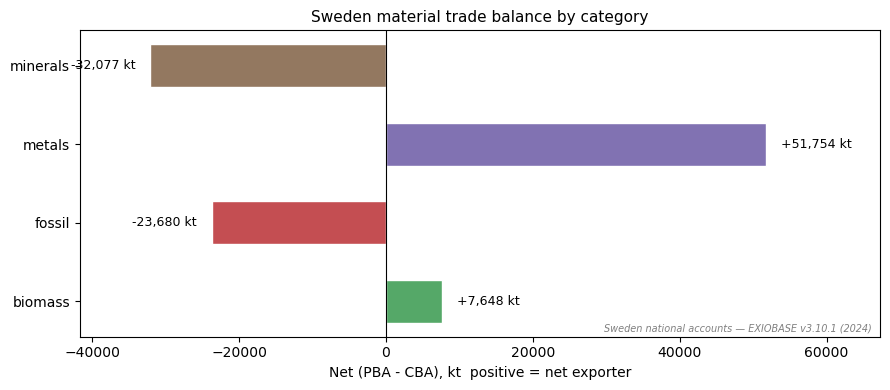

2026-04-16 16:31:48,387 INFO Chart 1 saved


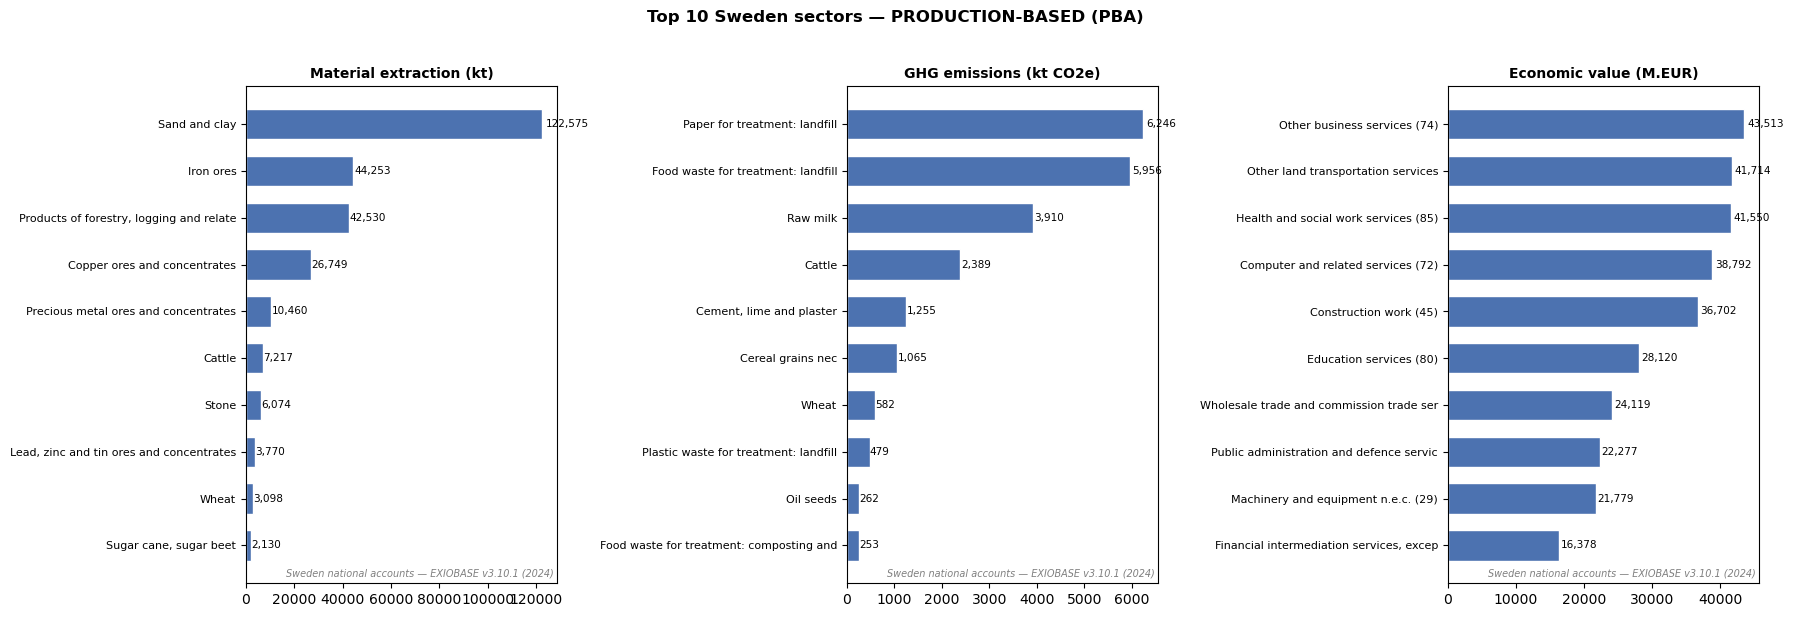

2026-04-16 16:31:49,175 INFO Chart 2 saved


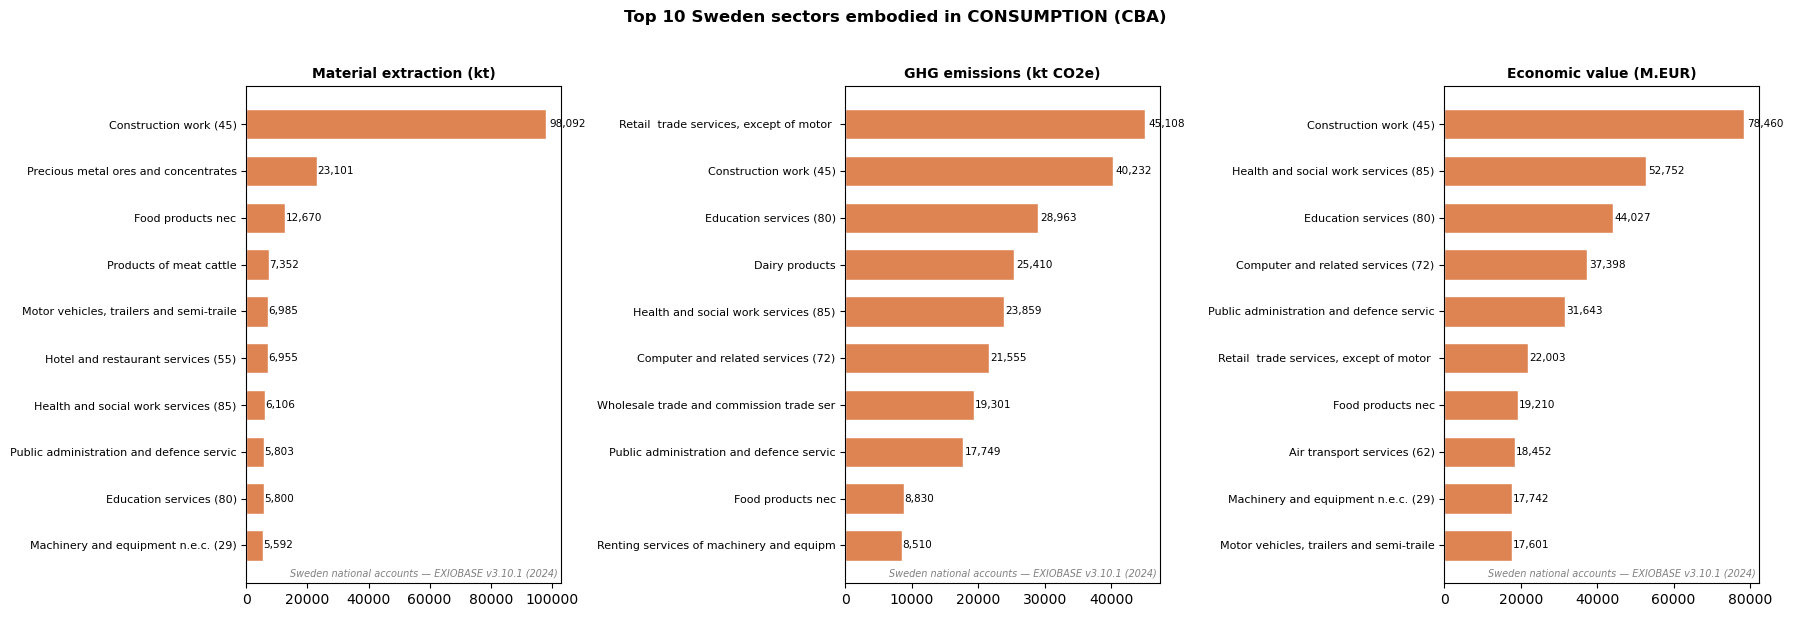

2026-04-16 16:31:49,934 INFO Chart 3 saved


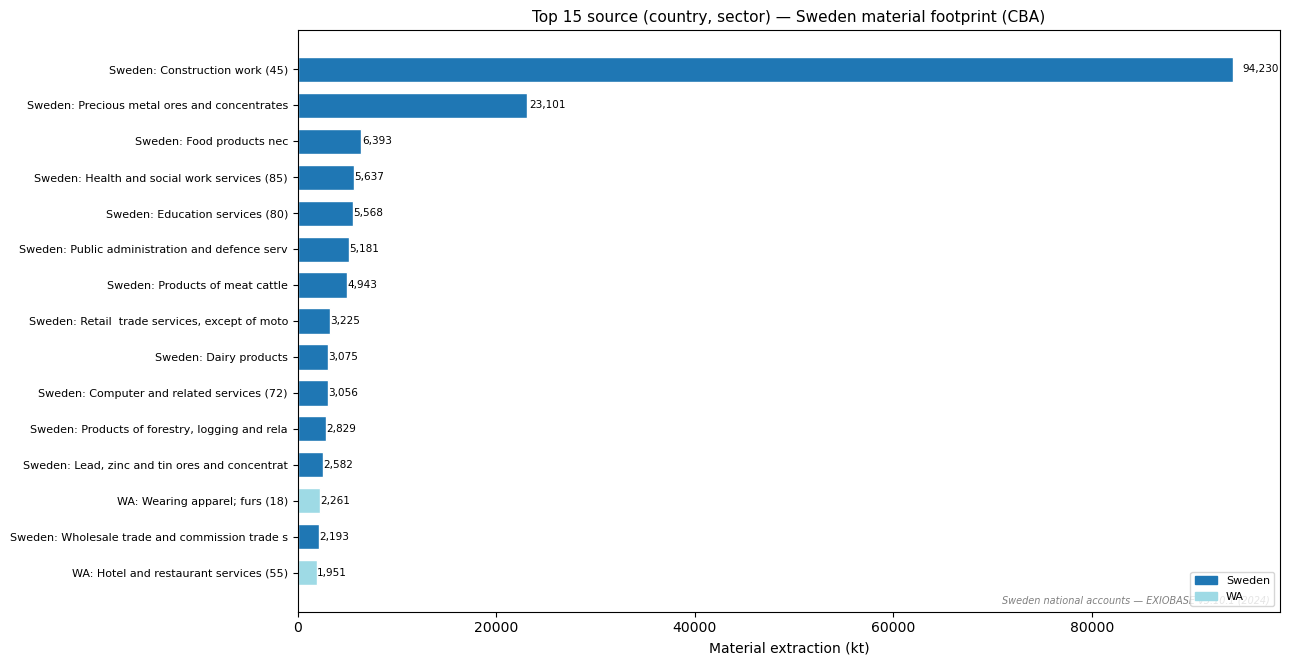

2026-04-16 16:31:50,366 INFO chart4_sweden_source_sectors_material.png saved


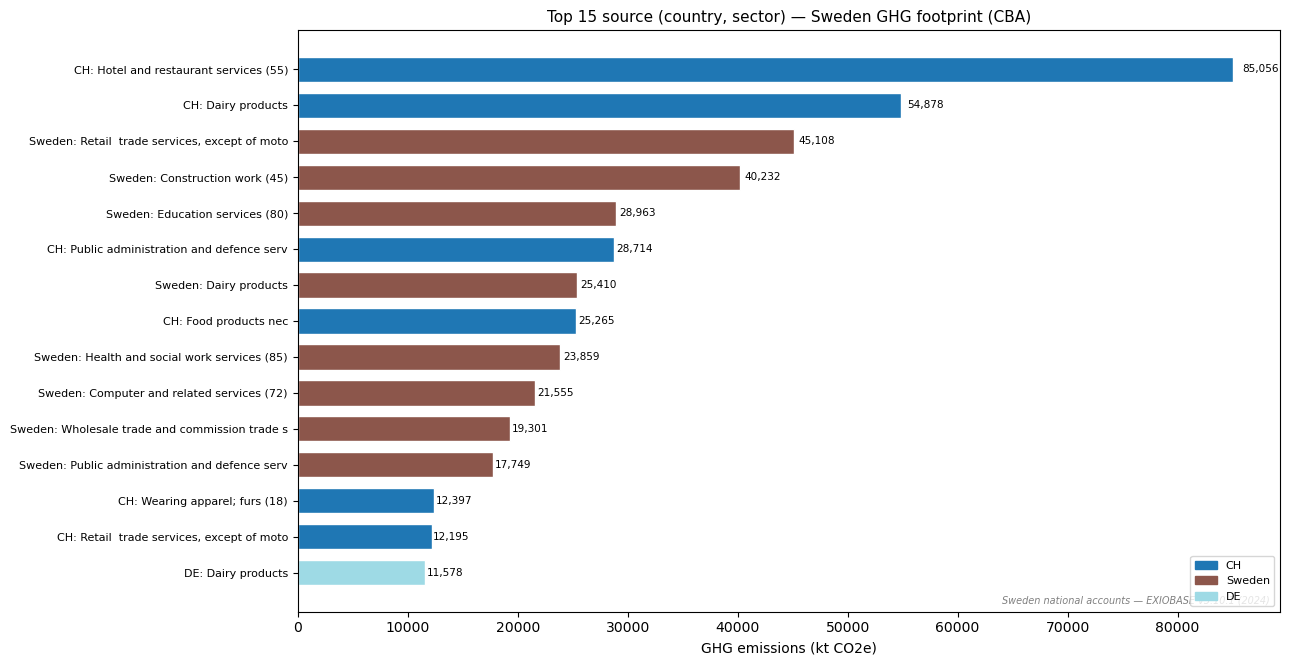

2026-04-16 16:31:50,812 INFO chart5_sweden_source_sectors_ghg.png saved


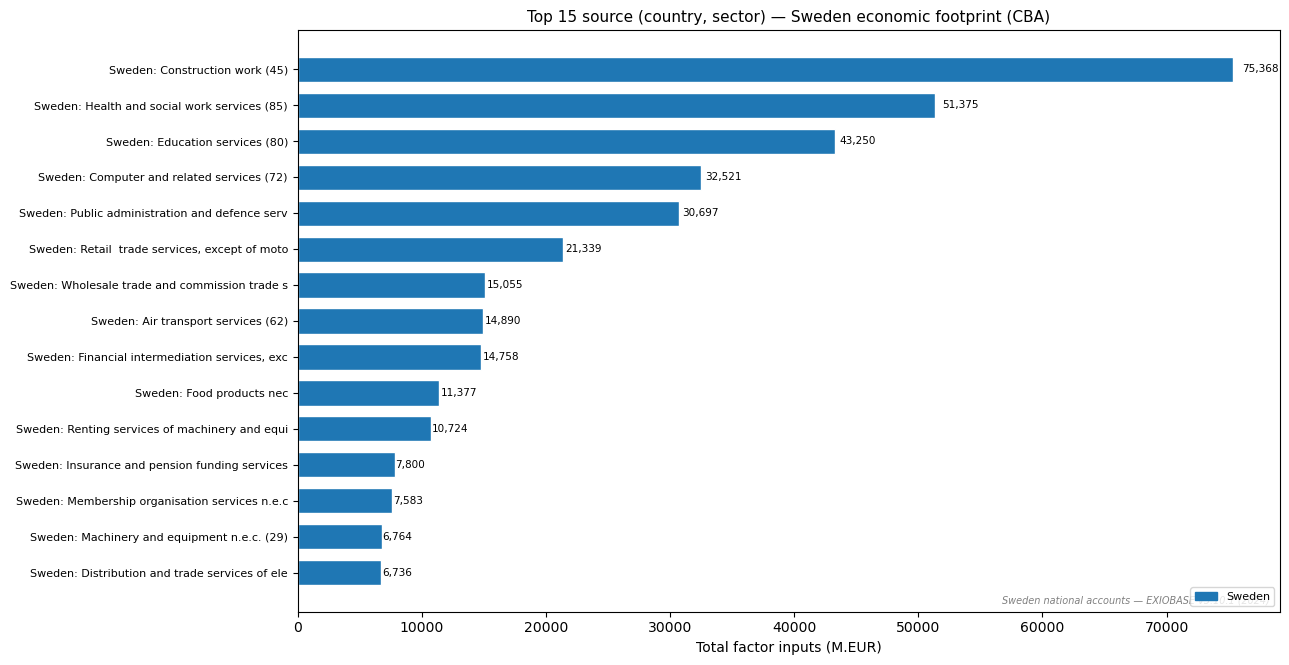

2026-04-16 16:31:51,276 INFO chart6_sweden_source_sectors_economic.png saved



All charts saved to: results_sweden


In [12]:
PROXY_NOTE = f'Sweden national accounts — EXIOBASE v3.10.1 ({BASE_YEAR})'
C_PBA = '#4C72B0'
C_CBA = '#DD8452'
CAT_COLORS = {
    'biomass': '#55A868', 'fossil': '#C44E52',
    'metals': '#8172B2', 'minerals': '#937860'
}

def add_note(ax):
    ax.text(0.99, 0.01, PROXY_NOTE, transform=ax.transAxes,
            fontsize=7, color='grey', ha='right', va='bottom', style='italic')

def fmt_pair(idx):
    c, s = idx
    return f"{'Sweden' if c == SWEDEN_CODE else c}: {s[:38]}"

def country_sector_chart(top_pairs, xlabel, title, filename):
    labels   = [fmt_pair(i) for i in top_pairs.index]
    vals     = top_pairs.values
    unique_c = list(dict.fromkeys(i[0] for i in top_pairs.index))
    cmap     = matplotlib.colormaps.get_cmap('tab20').resampled(
                   max(len(unique_c), 1))
    c_map    = {c: cmap(i) for i, c in enumerate(unique_c)}
    colors   = [c_map[i[0]] for i in top_pairs.index]
    fig, ax  = plt.subplots(figsize=(13, max(6, len(labels) * 0.45)))
    y        = np.arange(len(labels))
    ax.barh(y, vals, color=colors, edgecolor='white', height=0.7)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_title(title, fontsize=11)
    patches = [mpatches.Patch(color=c_map[c],
               label='Sweden' if c == SWEDEN_CODE else c)
               for c in unique_c]
    ax.legend(handles=patches, loc='lower right', fontsize=8)
    for i, v in enumerate(vals):
        ax.text(v * 1.01, i, f'{v:,.0f}', va='center', fontsize=7.5)
    add_note(ax)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=150, bbox_inches='tight')
    plt.show()
    log.info(f'{filename} saved')


# Chart 1: Net material trade balance
fig, ax = plt.subplots(figsize=(9, 4))
cats = results['material']['pba'].index.tolist()
net  = (results['material']['pba'] - results['material']['cba']).values
cols = [CAT_COLORS.get(c, '#999') for c in cats]
bars = ax.barh(cats, net, color=cols, edgecolor='white', height=0.55)
ax.axvline(0, color='black', linewidth=0.8)
rng = max(abs(net)) * 0.04
for bar, val in zip(bars, net):
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + rng * (1 if val >= 0 else -1),
            bar.get_y() + bar.get_height() / 2,
            f'{val:+,.0f} kt', va='center', ha=ha, fontsize=9)
ax.set_xlabel('Net (PBA - CBA), kt  positive = net exporter', fontsize=10)
ax.set_title('Sweden material trade balance by category', fontsize=11)
ax.set_xlim(min(net) * 1.3, max(net) * 1.3)
add_note(ax)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart1_sweden_material_balance.png',
            dpi=150, bbox_inches='tight')
plt.show()
log.info('Chart 1 saved')


# Chart 2: Top 10 PBA
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
panels = [
    ('Material extraction (kt)',  top['material']['pba_top']),
    ('GHG emissions (kt CO2e)',   top['ghg']['pba_top']),
    ('Economic value (M.EUR)',    top['factor_inputs']['pba_top']),
]
for ax, (title, data) in zip(axes, panels):
    secs = [str(s)[:40] for s in data.index]
    vals = data.values
    y    = np.arange(len(secs))
    ax.barh(y, vals, color=C_PBA, edgecolor='white', height=0.65)
    ax.set_yticks(y)
    ax.set_yticklabels(secs, fontsize=8)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=10, fontweight='bold')
    for i, v in enumerate(vals):
        ax.text(v * 1.01, i, f'{v:,.0f}', va='center', fontsize=7.5)
    add_note(ax)
fig.suptitle('Top 10 Sweden sectors — PRODUCTION-BASED (PBA)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart2_sweden_top_sectors_PBA.png',
            dpi=150, bbox_inches='tight')
plt.show()
log.info('Chart 2 saved')


# Chart 3: Top 10 CBA
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
panels_cba = [
    ('Material extraction (kt)',  top['material']['cba_top']),
    ('GHG emissions (kt CO2e)',   top['ghg']['cba_top']),
    ('Economic value (M.EUR)',    top['factor_inputs']['cba_top']),
]
for ax, (title, data) in zip(axes, panels_cba):
    secs = [str(s)[:40] for s in data.index]
    vals = data.values
    y    = np.arange(len(secs))
    ax.barh(y, vals, color=C_CBA, edgecolor='white', height=0.65)
    ax.set_yticks(y)
    ax.set_yticklabels(secs, fontsize=8)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=10, fontweight='bold')
    for i, v in enumerate(vals):
        ax.text(v * 1.01, i, f'{v:,.0f}', va='center', fontsize=7.5)
    add_note(ax)
fig.suptitle('Top 10 Sweden sectors embodied in CONSUMPTION (CBA)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart3_sweden_top_sectors_CBA.png',
            dpi=150, bbox_inches='tight')
plt.show()
log.info('Chart 3 saved')


if 'material' in cs:
    country_sector_chart(
        cs['material']['top_pairs'], 'Material extraction (kt)',
        'Top 15 source (country, sector) — Sweden material footprint (CBA)',
        'chart4_sweden_source_sectors_material.png')

if 'ghg' in cs:
    country_sector_chart(
        cs['ghg']['top_pairs'], 'GHG emissions (kt CO2e)',
        'Top 15 source (country, sector) — Sweden GHG footprint (CBA)',
        'chart5_sweden_source_sectors_ghg.png')

if 'factor_inputs' in cs:
    country_sector_chart(
        cs['factor_inputs']['top_pairs'], 'Total factor inputs (M.EUR)',
        'Top 15 source (country, sector) — Sweden economic footprint (CBA)',
        'chart6_sweden_source_sectors_economic.png')

print(f'\nAll charts saved to: {OUTPUT_DIR}')

## Summary

In [13]:
print('=' * 70)
print('SUMMARY — Sweden national resource and emission accounts')
print('=' * 70)
print(f'Base year  : {BASE_YEAR}')
print(f'EXIOBASE   : v3.10.1 (March 2026)')
print()

print('--- DIMENSION 1: Material extraction (kt) ---')
print(f"  {'Category':>12}  {'PBA':>12}  {'CBA':>12}  {'Net':>12}  Direction")
for cat in results['material']['pba'].index:
    pba = results['material']['pba'][cat]
    cba = results['material']['cba'][cat]
    net = pba - cba
    print(f"  {cat:>12}  {pba:>12,.0f}  {cba:>12,.0f}  {net:>12,.0f}  "
          f"{'net exporter' if net > 0 else 'NET IMPORTER'}")
print()

print('--- DIMENSION 2: GHG emissions (kt CO2e) ---')
print(f"  {'Category':>25}  {'PBA':>12}  {'CBA':>12}  {'Net':>12}  Direction")
for cat in results['ghg']['pba'].index:
    pba = results['ghg']['pba'][cat]
    cba = results['ghg']['cba'][cat]
    net = pba - cba
    print(f"  {cat:>25}  {pba:>12,.0f}  {cba:>12,.0f}  {net:>12,.0f}  "
          f"{'net exporter' if net > 0 else 'NET IMPORTER'}")
print()

print('--- DIMENSION 3: Economic value — factor inputs (M.EUR) ---')
pba_fi = results['factor_inputs']['pba_total']
cba_fi = results['factor_inputs']['cba_total']
print(f"  PBA (Sweden production value) : {pba_fi:>14,.0f} M.EUR")
print(f"  CBA (Sweden consumption value): {cba_fi:>14,.0f} M.EUR")
print(f"  Net (PBA - CBA)               : {pba_fi - cba_fi:>14,.0f} M.EUR")

SUMMARY — Sweden national resource and emission accounts
Base year  : 2024
EXIOBASE   : v3.10.1 (March 2026)

--- DIMENSION 1: Material extraction (kt) ---
      Category           PBA           CBA           Net  Direction
       biomass        64,372        56,724         7,648  net exporter
        fossil           201        23,881       -23,680  NET IMPORTER
        metals        85,280        33,525        51,754  net exporter
      minerals       128,673       160,750       -32,077  NET IMPORTER

--- DIMENSION 2: GHG emissions (kt CO2e) ---
                   Category           PBA           CBA           Net  Direction
         GHG_fossil_CO2e_kt        24,927       783,346      -758,419  NET IMPORTER
       GHG_biogenic_CO2e_kt           428         8,068        -7,640  NET IMPORTER

--- DIMENSION 3: Economic value — factor inputs (M.EUR) ---
  PBA (Sweden production value) :        561,537 M.EUR
  CBA (Sweden consumption value):        537,934 M.EUR
  Net (PBA - CBA)         